# Task 4 — Experimentos de validación metodológica (WDA)

Este cuaderno implementa seis experimentos que complementan el pipeline de `task3_v2` / `exp_wda`,
orientados a validar las decisiones metodológicas de la memoria:

| # | Experimento | Pregunta que responde |
|---|-------------|----------------------|
| 1 | **Baseline sin red neuronal** (PCA sobre espectros crudos) | ¿El espacio latente aporta sobre el espectro directo? |
| 2 | **Selección de ε por k-distance** | ¿Cómo justificar el ε de DBSCAN (en vez de ε=1.5 manual)? |
| 3 | **Eigengap del Laplaciano** | ¿Qué k sugiere la teoría espectral, independiente del Silhouette? |
| 4 | **GMM + Agglomerative + HDBSCAN** | ¿Los candidatos del Cap. 4 superan a Spectral/DBSCAN? |
| 5 | **S/N por cluster (confusores)** | ¿Los clusters separan física o calidad de datos? |
| 6 | **Test nulo con datos sintéticos** | ¿El Silhouette observado excede lo esperable por azar? |

Las funciones base (`process_spectrum`, extractores, métricas, DBCV) se reutilizan tal cual
desde `task3_v2` para mantener consistencia total con los experimentos previos.

## 0. Setup y carga de datos

Mismas rutas, mismo modelo, mismo muestreo (`n = 1100`, `random_state = 42`) que `exp_wda`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from tensorflow.keras.models import load_model, Model
from tensorflow.keras import layers

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering, AgglomerativeClustering, HDBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors, kneighbors_graph
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

from scipy.stats import kruskal
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.sparse.csgraph import laplacian as csgraph_laplacian
from scipy.spatial.distance import cdist
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.sparse import csr_matrix

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
project_dir = Path().resolve().parent

model_path  = os.path.join(project_dir, r"models\model_4C_3FC.h5")
data_path   = os.path.join(project_dir, r"data\raw\sdss_dat_files")
labels_path = os.path.join(project_dir, r"data\raw\label_data")

print(project_dir)

C:\Users\javip\OneDrive - Universidad Técnica Federico Santa María\6to año\elo308\ML_NPF


In [3]:
# etiquetas + indice de archivos .dat (identico a exp_wda)
fields = ['File Name', 'MJD', 'Target ID', 'DB ID', 'Classification', 'Data Quality']
raw_labels_df = pd.DataFrame()

for filename in os.listdir(labels_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(labels_path, filename)
        df = pd.read_csv(file_path, usecols=fields)
        raw_labels_df = pd.concat([raw_labels_df, df], ignore_index=True)

file_dict = {}
for folder in os.listdir(data_path):
    folder_full_path = os.path.join(data_path, folder)
    if os.path.isdir(folder_full_path):
        for filename in os.listdir(folder_full_path):
            if filename.endswith('.dat'):
                key = filename.split('-')[-2] + '_' + filename.split('_')[-1]
                file_dict[key] = os.path.join(folder, filename)

print(f"etiquetas: {raw_labels_df.shape[0]} | archivos .dat indexados: {len(file_dict)}")

etiquetas: 35253 | archivos .dat indexados: 33698


In [4]:
full_model = load_model(model_path)
dummy_input = np.zeros((1, 3750, 1), dtype=np.float32)
_ = full_model.predict(dummy_input, verbose=0)
print("modelo cargado")

c:\Users\javip\OneDrive - Universidad Técnica Federico Santa María\6to año\elo308\ML_NPF\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\javip\OneDrive - Universidad Técnica Federico Santa María\6to año\elo308\ML_NPF\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


modelo cargado


In [5]:
# ---------- funciones base reutilizadas de task3_v2 ----------

def process_spectrum_with_wavelength(file_path):
    try:
        sed = np.loadtxt(file_path, unpack=True)
        wave = sed[0, 48:-400]
        flux = sed[1, 48:-400]

        if len(flux) > 3750:
            diff = len(flux) - 3750
            start = diff // 2
            flux = flux[start:start + 3750]
            wave = wave[start:start + 3750]
        elif len(flux) < 3750:
            pad_len = 3750 - len(flux)
            flux = np.pad(flux, (0, pad_len), mode='constant')
            if len(wave) > 1:
                dw = np.nanmedian(np.diff(wave))
                extra_wave = wave[-1] + dw * np.arange(1, pad_len + 1)
                wave = np.concatenate([wave, extra_wave])
            else:
                wave = np.pad(wave, (0, pad_len), mode='constant')

        norm_val = flux[2100]
        if norm_val == 0 or np.isnan(norm_val):
            norm_val = np.nanmean(flux)
        if norm_val == 0 or np.isnan(norm_val):
            return None, None

        flux = flux / norm_val
        if np.isnan(flux).any() or np.isnan(wave).any():
            return None, None

        return wave.astype(np.float32), flux.astype(np.float32)
    except Exception:
        return None, None


def build_class_dataframe(class_name):
    star_df = raw_labels_df[raw_labels_df['Classification'] == class_name].copy()
    spectrum_list = []
    for _, row in star_df.iterrows():
        filekey = str(row['MJD']) + '_' + str(row['Target ID']) + '.dat'
        if filekey in file_dict:
            spectrum_list.append({'filename': file_dict[filekey],
                                  'classID': row['Classification']})
    return pd.DataFrame(spectrum_list)


def load_class_spectra_DRACULA_with_wavelength(class_name, n_samples=1100, random_state=42):
    spectrum_df = build_class_dataframe(class_name)
    print(f"{class_name}: disponibles con match a .dat = {len(spectrum_df)}")
    if len(spectrum_df) < n_samples:
        raise ValueError(f"No hay suficientes espectros para {class_name}.")

    selected_df = spectrum_df.sample(n=n_samples, random_state=random_state).reset_index(drop=True)

    wave_list, flux_list, valid_rows = [], [], []
    for _, row in selected_df.iterrows():
        f_path = os.path.join(data_path, row['filename'])
        wave, flux = process_spectrum_with_wavelength(f_path)
        if wave is not None and flux is not None:
            wave_list.append(wave)
            flux_list.append(flux)
            valid_rows.append(row)

    W_final = np.array(wave_list, dtype=np.float32)
    X_final = np.array(flux_list, dtype=np.float32)
    X_input = X_final.reshape((X_final.shape[0], X_final.shape[1], 1))
    valid_df = pd.DataFrame(valid_rows).reset_index(drop=True)

    print(f"{class_name}: espectros validos finales = {X_input.shape[0]}")
    return W_final, X_final, X_input, valid_df

In [6]:
# ---------- extractores y reduccion (identicos a task3_v2) ----------

def build_extractor_until(layer_name, full_model):
    input_layer = layers.Input(shape=(3750, 1))
    x = input_layer
    for layer in full_model.layers:
        x = layer(x)
        if layer.name == layer_name:
            break
    return Model(inputs=input_layer, outputs=x)

flatten_extractor = build_extractor_until("flatten", full_model)
dense_extractor   = build_extractor_until("dense", full_model)
dense1_extractor  = build_extractor_until("dense_1", full_model)
dense2_extractor  = build_extractor_until("dense_2", full_model)


def extract_layer_features(X_input):
    flatten_features = flatten_extractor.predict(X_input, batch_size=64, verbose=1)
    dense_features   = dense_extractor.predict(X_input, batch_size=64, verbose=1)
    dense1_features  = dense1_extractor.predict(X_input, batch_size=64, verbose=1)
    dense2_features  = dense2_extractor.predict(X_input, batch_size=64, verbose=1)
    return flatten_features, dense_features, dense1_features, dense2_features


def reduce_all_to_32(flatten_features, dense_features, dense1_features, dense2_features):
    flatten_32 = PCA(n_components=32, random_state=42).fit_transform(flatten_features)
    dense_32   = PCA(n_components=32, random_state=42).fit_transform(dense_features)
    dense1_32  = PCA(n_components=32, random_state=42).fit_transform(dense1_features)
    dense2_32  = dense2_features.copy()
    return {"flatten": flatten_32, "dense": dense_32,
            "dense_1": dense1_32, "dense_2": dense2_32}

In [7]:
# ---------- metricas (identicas a task3_v2) ----------

def compute_cluster_metrics(Xs, labels):
    """DB, CH y Silhouette sobre el espacio escalado. Excluye ruido (-1)."""
    mask         = labels != -1
    Xs_clean     = Xs[mask]
    labels_clean = labels[mask]

    n_clusters = len(np.unique(labels_clean))
    n_noise    = int(np.sum(~mask))

    if n_clusters < 2:
        return {"n_clusters": n_clusters, "n_noise": n_noise,
                "silhouette": None, "davies_bouldin": None, "calinski_harabasz": None}

    return {"n_clusters": n_clusters, "n_noise": n_noise,
            "silhouette": round(silhouette_score(Xs_clean, labels_clean), 6),
            "davies_bouldin": round(davies_bouldin_score(Xs_clean, labels_clean), 6),
            "calinski_harabasz": round(calinski_harabasz_score(Xs_clean, labels_clean), 4)}


def dbcv_score(X, labels, noise_id=-1):
    """DBCV en [-1, 1], mas alto = mejor. O(n^2)."""
    X      = np.asarray(X, dtype=np.float64)
    labels = np.asarray(labels)
    mask   = labels != noise_id
    X      = X[mask]
    labels = labels[mask]

    unique = np.unique(labels)
    if len(unique) < 2:
        return np.nan
    n = X.shape[0]

    D = cdist(X, X)
    np.fill_diagonal(D, np.inf)

    core_dists = np.full(n, np.inf)
    for label in unique:
        idx = np.where(labels == label)[0]
        if len(idx) <= 1:
            continue
        D_sub = D[np.ix_(idx, idx)]
        with np.errstate(divide='ignore'):
            inv_d = np.where(np.isinf(D_sub), 0.0, 1.0 / D_sub)
        harmonic_core = (len(idx) - 1) / inv_d.sum(axis=1)
        for k, i in enumerate(idx):
            core_dists[i] = harmonic_core[k]

    D_fin = np.where(np.isinf(D), 0.0, D)
    mrd = np.maximum(np.maximum(core_dists[:, None], core_dists[None, :]), D_fin)

    mst = minimum_spanning_tree(csr_matrix(mrd)).toarray()
    mst_sym = np.maximum(mst, mst.T)

    dsc = {}
    for label in unique:
        idx = np.where(labels == label)[0]
        internal = mst_sym[np.ix_(idx, idx)]
        dsc[label] = float(internal.max()) if internal.size > 0 else 0.0

    dspc = {}
    for i, li in enumerate(unique):
        for j, lj in enumerate(unique):
            if i >= j:
                continue
            ix_i = np.where(labels == li)[0]
            ix_j = np.where(labels == lj)[0]
            val = float(mrd[np.ix_(ix_i, ix_j)].min())
            dspc[(li, lj)] = dspc[(lj, li)] = val

    validity = {}
    for label in unique:
        min_sep = min(dspc[(label, o)] for o in unique if o != label)
        denom = max(min_sep, dsc[label])
        validity[label] = 0.0 if denom == 0 else (min_sep - dsc[label]) / denom

    score = sum((np.sum(labels == label) / n) * validity[label] for label in unique)
    return round(float(score), 6)

In [8]:
# ---------- carga WDA + embeddings + espacios escalados ----------
W_wda, X_wda_spec, X_wda_input, df_wda = load_class_spectra_DRACULA_with_wavelength(
    "WDA", n_samples=1100, random_state=RANDOM_STATE)

f_feat, d_feat, d1_feat, d2_feat = extract_layer_features(X_wda_input)
repr_wda_32 = reduce_all_to_32(f_feat, d_feat, d1_feat, d2_feat)

CAPAS = ["flatten", "dense", "dense_1", "dense_2"]

# espacios estandarizados listos para clustering (igual que en exp_wda)
Xs_wda = {capa: StandardScaler().fit_transform(repr_wda_32[capa]) for capa in CAPAS}
print({k: v.shape for k, v in Xs_wda.items()})

WDA: disponibles con match a .dat = 13723
WDA: espectros validos finales = 1100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
{'flatten': (1100, 32), 'dense': (1100, 32), 'dense_1': (1100, 32), 'dense_2': (1100, 32)}


## Experimento 1 — Baseline sin red neuronal

**Motivación.** Toda la tesis descansa en la premisa de que las representaciones latentes de la
red preentrenada son mejores insumos para el clustering que el espectro crudo. Este experimento
la pone a prueba con un control directo: se aplica **exactamente el mismo pipeline**
(PCA a 32 dimensiones → StandardScaler → Spectral Clustering → métricas internas) pero tomando
como entrada el espectro normalizado de 3.750 puntos en lugar de la salida de una capa de la red.
La única variable que cambia es la presencia de la red.

- Si las capas superan al baseline → evidencia empírica de que la red aporta estructura.
- Si el baseline empata o gana → los clusters reflejan variación ya accesible linealmente
  desde el flujo, y la premisa debe matizarse.

In [9]:
# baseline: PCA(32) directo sobre los espectros crudos normalizados
pca_baseline = PCA(n_components=32, random_state=RANDOM_STATE)
baseline_32 = pca_baseline.fit_transform(X_wda_spec)
Xs_baseline = StandardScaler().fit_transform(baseline_32)

print(f"varianza explicada por PCA(32) sobre espectros crudos: "
      f"{pca_baseline.explained_variance_ratio_.sum():.3f}")

# todos los espacios a comparar, con el baseline incluido
ESPACIOS = {"baseline (crudo)": Xs_baseline, **Xs_wda}


def run_spectral(Xs, k, seed=RANDOM_STATE):
    sc = SpectralClustering(n_clusters=k, affinity="nearest_neighbors",
                            assign_labels="kmeans", random_state=seed)
    return sc.fit_predict(Xs)


rows = []
for nombre, Xs in ESPACIOS.items():
    for k in [2, 3, 4]:
        labels = run_spectral(Xs, k)
        m = compute_cluster_metrics(Xs, labels)
        rows.append({"espacio": nombre, "k": k, **m})

tabla_exp1 = pd.DataFrame(rows).drop(columns=["n_noise"])
tabla_exp1_piv = tabla_exp1.pivot(index="espacio", columns="k",
                                  values="silhouette").loc[list(ESPACIOS.keys())]
print("=== Silhouette por espacio y k (Spectral Clustering) ===")
display(tabla_exp1_piv.round(4))
display(tabla_exp1.round(4))

varianza explicada por PCA(32) sobre espectros crudos: 0.974
=== Silhouette por espacio y k (Spectral Clustering) ===


k,2,3,4
espacio,,,
baseline (crudo),-0.0379,-0.0155,-0.0950
flatten,0.0668,-0.0472,-0.0258
dense,0.0973,-0.0692,-0.0642
dense_1,0.0831,0.0238,-0.0056
dense_2,0.3845,0.2710,0.2007


,espacio,k,n_clusters,silhouette,davies_bouldin,calinski_harabasz
0,baseline (crudo),2,2,-0.0379,2.4874,20.0437
1,baseline (crudo),3,3,-0.0155,2.2472,20.6329
2,baseline (crudo),4,4,-0.0950,2.1361,16.1142
3,flatten,2,2,0.0668,2.2879,21.4947
4,flatten,3,3,-0.0472,2.6617,20.2384
5,flatten,4,4,-0.0258,3.3007,18.8727
6,dense,2,2,0.0973,5.0157,23.5887
7,dense,3,3,-0.0692,4.2574,22.0086
8,dense,4,4,-0.0642,4.0526,21.4740
9,dense_1,2,2,0.0831,5.1219,25.1293


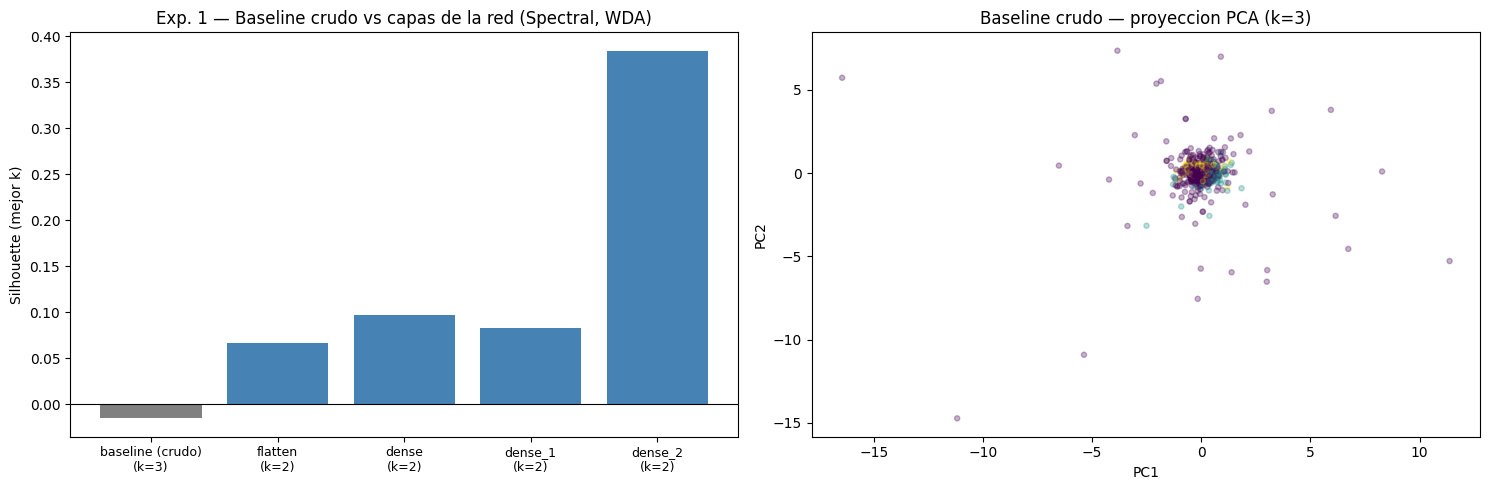

In [10]:
# visualizacion: barras de silhouette + proyeccion 2D del baseline
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# barras comparativas para el mejor k de cada espacio
best_por_espacio = tabla_exp1.loc[tabla_exp1.groupby("espacio")["silhouette"].idxmax()]
best_por_espacio = best_por_espacio.set_index("espacio").loc[list(ESPACIOS.keys())]
colores = ["gray"] + ["steelblue"] * 4
axes[0].bar(range(len(best_por_espacio)), best_por_espacio["silhouette"], color=colores)
axes[0].set_xticks(range(len(best_por_espacio)))
axes[0].set_xticklabels([f"{e}\n(k={int(k)})" for e, k in
                         zip(best_por_espacio.index, best_por_espacio["k"])],
                        rotation=0, fontsize=9)
axes[0].set_ylabel("Silhouette (mejor k)")
axes[0].set_title("Exp. 1 — Baseline crudo vs capas de la red (Spectral, WDA)")
axes[0].axhline(0, color="black", linewidth=0.8)

# scatter 2D (PCA) del baseline con su mejor k
best_k_baseline = int(best_por_espacio.loc["baseline (crudo)", "k"])
labels_bl = run_spectral(Xs_baseline, best_k_baseline)
proj = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(Xs_baseline)
axes[1].scatter(proj[:, 0], proj[:, 1], c=labels_bl, cmap="viridis", s=14, alpha=0.3)
axes[1].set_title(f"Baseline crudo — proyeccion PCA (k={best_k_baseline})")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()

**Qué mirar:** compara la fila `baseline (crudo)` contra `dense_2` en la tabla. Si
`dense_2` (k=2) mantiene un Silhouette claramente superior al mejor baseline, la premisa de la
tesis queda demostrada empíricamente. Anota ambos números para la memoria (Sección 6 —
Desarrollo).

## Experimento 2 — Selección de ε por gráfico k-distance

**Motivación.** El ε = 1.5 usado hasta ahora fue una elección manual. El método propuesto en el
paper original de DBSCAN (Ester et al. 1996) consiste en graficar, para cada punto, la distancia
a su k-ésimo vecino más cercano (con k = `min_samples`) ordenada de forma decreciente: el
**codo** de esa curva indica el ε que separa las regiones densas del ruido.

Se estima el codo automáticamente con el método geométrico (punto de máxima distancia a la
recta que une los extremos de la curva) y se compara el DBSCAN resultante contra el histórico
(ε = 1.5).

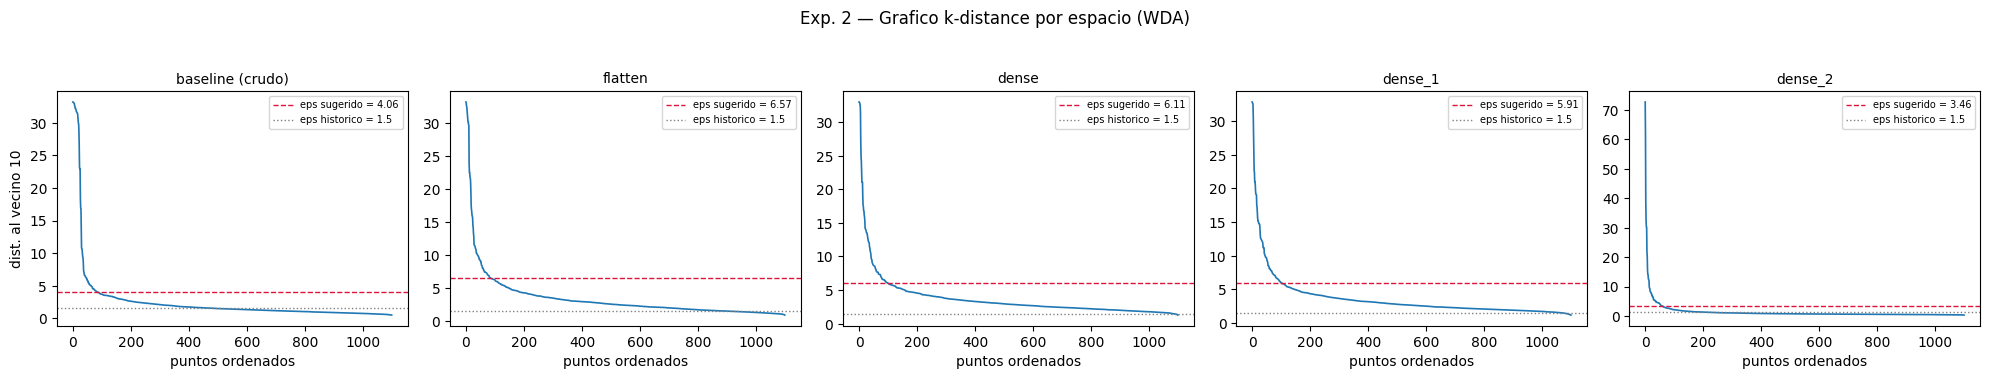

{'baseline (crudo)': 4.06, 'flatten': 6.57, 'dense': 6.112, 'dense_1': 5.91, 'dense_2': 3.457}


In [11]:
def k_distance_curve(Xs, min_samples=10):
    """distancia (ordenada descendente) de cada punto a su k-esimo vecino."""
    nn = NearestNeighbors(n_neighbors=min_samples).fit(Xs)
    dists, _ = nn.kneighbors(Xs)
    return np.sort(dists[:, -1])[::-1]


def suggest_eps(k_dists):
    """codo geometrico: punto de la curva mas alejado de la recta extremo-extremo."""
    n = len(k_dists)
    x = np.arange(n, dtype=float)
    y = k_dists.astype(float)
    p1 = np.array([x[0], y[0]]); p2 = np.array([x[-1], y[-1]])
    seg = p2 - p1
    seg_norm = seg / np.linalg.norm(seg)
    vecs = np.stack([x, y], axis=1) - p1
    proy = vecs @ seg_norm
    dist_perp = np.linalg.norm(vecs - np.outer(proy, seg_norm), axis=1)
    idx = int(np.argmax(dist_perp))
    return float(y[idx]), idx


MIN_SAMPLES = 10
fig, axes = plt.subplots(1, len(ESPACIOS), figsize=(20, 3.6), sharey=False)
eps_sugeridos = {}

for ax, (nombre, Xs) in zip(axes, ESPACIOS.items()):
    kd = k_distance_curve(Xs, MIN_SAMPLES)
    eps_hat, idx = suggest_eps(kd)
    eps_sugeridos[nombre] = eps_hat
    ax.plot(kd, lw=1.2)
    ax.axhline(eps_hat, color="crimson", ls="--", lw=1,
               label=f"eps sugerido = {eps_hat:.2f}")
    ax.axhline(1.5, color="gray", ls=":", lw=1, label="eps historico = 1.5")
    ax.set_title(nombre, fontsize=10)
    ax.set_xlabel(f"puntos ordenados")
    ax.legend(fontsize=7)
axes[0].set_ylabel(f"dist. al vecino {MIN_SAMPLES}")
plt.suptitle("Exp. 2 — Grafico k-distance por espacio (WDA)", y=1.04)
plt.tight_layout()
plt.show()

print({k: round(v, 3) for k, v in eps_sugeridos.items()})

In [12]:
# DBSCAN con eps sugerido vs eps historico, por espacio
rows = []
for nombre, Xs in ESPACIOS.items():
    for eps_name, eps in [("sugerido", eps_sugeridos[nombre]), ("historico", 1.5)]:
        labels = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit_predict(Xs)
        m = compute_cluster_metrics(Xs, labels)
        dbcv = dbcv_score(Xs, labels) if m["n_clusters"] >= 2 else np.nan
        rows.append({"espacio": nombre, "eps": f"{eps:.2f} ({eps_name})",
                     "pct_ruido": round(100 * m["n_noise"] / len(labels), 1), **m,
                     "DBCV": dbcv})

tabla_exp2 = pd.DataFrame(rows)
print("=== DBSCAN: eps sugerido por k-distance vs eps historico (WDA) ===")
display(tabla_exp2.round(4))

=== DBSCAN: eps sugerido por k-distance vs eps historico (WDA) ===


,espacio,eps,pct_ruido,n_clusters,n_noise,silhouette,davies_bouldin,calinski_harabasz,DBCV
0,baseline (crudo),4.06 (sugerido),6.2,1,68,NaN,NaN,NaN,NaN
1,baseline (crudo),1.50 (historico),35.6,1,392,NaN,NaN,NaN,NaN
2,flatten,6.57 (sugerido),5.8,1,64,NaN,NaN,NaN,NaN
3,flatten,1.50 (historico),71.8,1,790,NaN,NaN,NaN,NaN
4,dense,6.11 (sugerido),6.6,1,73,NaN,NaN,NaN,NaN
5,dense,1.50 (historico),93.6,3,1030,0.2891,1.2437,25.6442,-0.2465
6,dense_1,5.91 (sugerido),6.8,1,75,NaN,NaN,NaN,NaN
7,dense_1,1.50 (historico),91.4,2,1005,0.1462,1.5471,10.4406,-0.3294
8,dense_2,3.46 (sugerido),4.0,1,44,NaN,NaN,NaN,NaN
9,dense_2,1.50 (historico),10.5,1,115,NaN,NaN,NaN,NaN


**Qué mirar:** para cada espacio, el ε sugerido debería producir una partición con menos
ruido masivo y DBCV más alto que ε = 1.5 en los espacios donde éste fallaba. Este resultado
justifica en la memoria la elección de ε y probablemente explique el caso WDB (todo ruido con
ε = 1.5): su codo estará en otro valor.

## Experimento 3 — Eigengap del Laplaciano (selección de k para Spectral)

**Motivación.** La heurística del *eigengap* (von Luxburg, 2007) indica que el número natural
de clusters corresponde al índice k donde se produce el mayor salto entre autovalores
consecutivos del Laplaciano normalizado del grafo de similitud. Es una evidencia para elegir k
**independiente del Silhouette**, derivada de la misma teoría en que se basa Spectral
Clustering.

Se construye el mismo grafo kNN que usa `SpectralClustering(affinity='nearest_neighbors')`
y se examinan los primeros 10 autovalores.

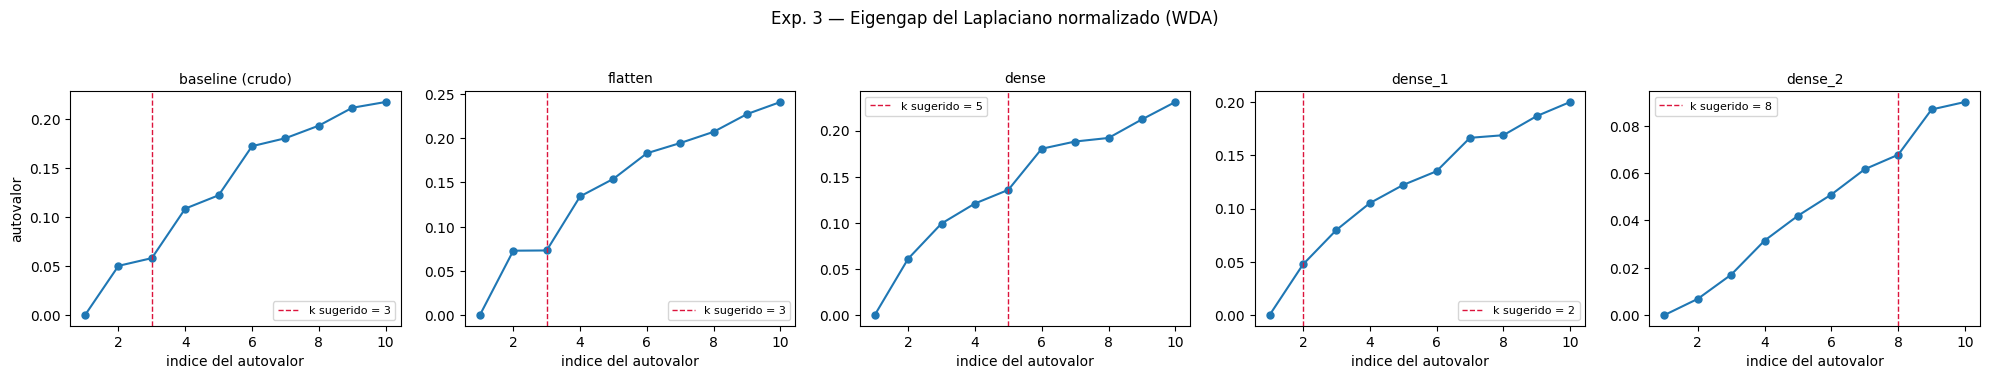

k sugerido por eigengap: {'baseline (crudo)': 3, 'flatten': 3, 'dense': 5, 'dense_1': 2, 'dense_2': 8}


In [13]:
def eigengap_analysis(Xs, n_neighbors=10, n_eigen=10):
    """autovalores mas pequenos del Laplaciano normalizado del grafo kNN simetrizado."""
    A = kneighbors_graph(Xs, n_neighbors=n_neighbors, mode="connectivity")
    A = 0.5 * (A + A.T)                      # simetrizacion (como SpectralClustering)
    L = csgraph_laplacian(A, normed=True)
    vals = np.linalg.eigvalsh(L.toarray())   # n=1100 -> denso es viable
    vals = np.sort(vals)[:n_eigen]
    gaps = np.diff(vals)
    k_sugerido = int(np.argmax(gaps[1:]) + 2)  # se ignora el gap trivial en k=1
    return vals, gaps, k_sugerido


fig, axes = plt.subplots(1, len(ESPACIOS), figsize=(20, 3.6))
resumen_eigengap = {}

for ax, (nombre, Xs) in zip(axes, ESPACIOS.items()):
    vals, gaps, k_hat = eigengap_analysis(Xs)
    resumen_eigengap[nombre] = k_hat
    ax.plot(range(1, len(vals) + 1), vals, "o-", ms=5)
    ax.axvline(k_hat, color="crimson", ls="--", lw=1, label=f"k sugerido = {k_hat}")
    ax.set_title(nombre, fontsize=10)
    ax.set_xlabel("indice del autovalor")
    ax.legend(fontsize=8)
axes[0].set_ylabel("autovalor")
plt.suptitle("Exp. 3 — Eigengap del Laplaciano normalizado (WDA)", y=1.04)
plt.tight_layout()
plt.show()

print("k sugerido por eigengap:", resumen_eigengap)

**Qué mirar:** compara el k del eigengap con el elegido por Silhouette en los
experimentos previos (k=2 para `dense_2`). Si coinciden, tienes dos criterios independientes
apuntando al mismo número de subgrupos — un argumento fuerte para la memoria y la defensa.

## Experimento 4 — Algoritmos candidatos faltantes: GMM, Agglomerative y HDBSCAN

**Motivación.** El Capítulo 4 de la memoria declara GMM, Agglomerative Clustering y HDBSCAN
como candidatos, pero hasta ahora no se habían ejecutado. Este experimento cierra esa
inconsistencia corriéndolos sobre los mismos espacios (foco en `dense_2`, la capa ganadora
para WDA) con las mismas métricas, de modo que la selección final de Spectral + DBSCAN quede
justificada empíricamente y no a priori.

- **GMM**: además de las métricas internas, entrega los criterios BIC/AIC para seleccionar k.
- **Agglomerative (Ward)**: entrega un dendrograma interpretable.
- **HDBSCAN**: elimina la dependencia de ε de DBSCAN; se valida con DBCV.

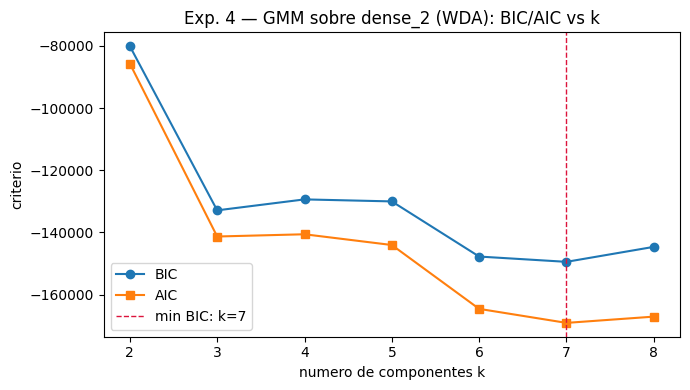

GMM (k=7 por BIC): {'n_clusters': 7, 'n_noise': 0, 'silhouette': 0.118126, 'davies_bouldin': 2.78356, 'calinski_harabasz': 223.7056}


In [14]:
# --- GMM sobre dense_2: seleccion de k por BIC/AIC ---
Xs_d2 = Xs_wda["dense_2"]
ks = range(2, 9)
bics, aics = [], []
for k in ks:
    gm = GaussianMixture(n_components=k, covariance_type="full",
                         random_state=RANDOM_STATE, n_init=3)
    gm.fit(Xs_d2)
    bics.append(gm.bic(Xs_d2))
    aics.append(gm.aic(Xs_d2))

k_bic = list(ks)[int(np.argmin(bics))]
k_aic = list(ks)[int(np.argmin(aics))]

plt.figure(figsize=(7, 4))
plt.plot(list(ks), bics, "o-", label="BIC")
plt.plot(list(ks), aics, "s-", label="AIC")
plt.axvline(k_bic, color="crimson", ls="--", lw=1, label=f"min BIC: k={k_bic}")
plt.xlabel("numero de componentes k"); plt.ylabel("criterio")
plt.title("Exp. 4 — GMM sobre dense_2 (WDA): BIC/AIC vs k")
plt.legend(); plt.tight_layout(); plt.show()

gm_best = GaussianMixture(n_components=k_bic, covariance_type="full",
                          random_state=RANDOM_STATE, n_init=3).fit(Xs_d2)
labels_gmm = gm_best.predict(Xs_d2)
metrics_gmm = compute_cluster_metrics(Xs_d2, labels_gmm)
print(f"GMM (k={k_bic} por BIC):", metrics_gmm)

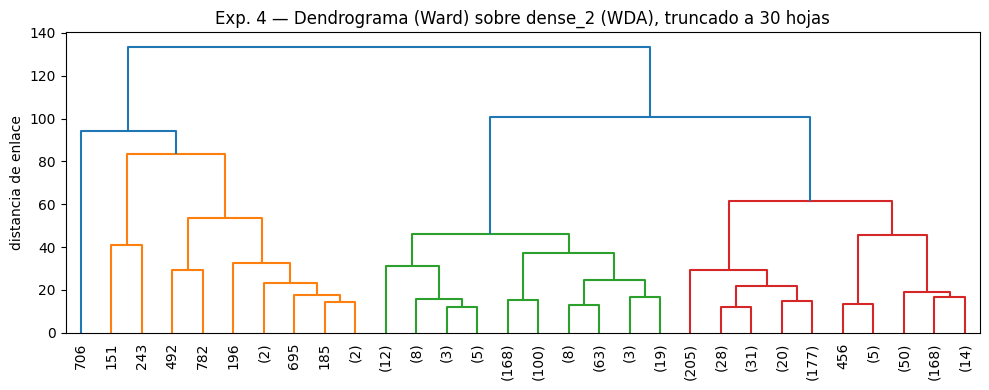

Agglomerative k=2: {'n_clusters': 2, 'n_noise': 0, 'silhouette': 0.871552, 'davies_bouldin': 1.10218, 'calinski_harabasz': 372.4565}
Agglomerative k=3: {'n_clusters': 3, 'n_noise': 0, 'silhouette': 0.353801, 'davies_bouldin': 1.116449, 'calinski_harabasz': 360.672}
Agglomerative k=4: {'n_clusters': 4, 'n_noise': 0, 'silhouette': 0.354622, 'davies_bouldin': 0.864138, 'calinski_harabasz': 399.8587}


In [15]:
# --- Agglomerative (Ward) sobre dense_2: dendrograma + metricas ---
Z = linkage(Xs_d2, method="ward")

plt.figure(figsize=(10, 4))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90)
plt.title("Exp. 4 — Dendrograma (Ward) sobre dense_2 (WDA), truncado a 30 hojas")
plt.ylabel("distancia de enlace")
plt.tight_layout(); plt.show()

resultados_agg = {}
for k in [2, 3, 4]:
    labels_agg = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(Xs_d2)
    resultados_agg[k] = compute_cluster_metrics(Xs_d2, labels_agg)
    print(f"Agglomerative k={k}:", resultados_agg[k])

In [16]:
# --- HDBSCAN sobre dense_2: grid pequeno de min_cluster_size ---
resultados_hdb = {}
for mcs in [10, 25, 50]:
    hdb = HDBSCAN(min_cluster_size=mcs, min_samples=MIN_SAMPLES)
    labels_hdb = hdb.fit_predict(Xs_d2)
    m = compute_cluster_metrics(Xs_d2, labels_hdb)
    dbcv = dbcv_score(Xs_d2, labels_hdb) if m["n_clusters"] >= 2 else np.nan
    resultados_hdb[mcs] = {**m, "DBCV": dbcv,
                           "pct_ruido": round(100 * m["n_noise"] / len(labels_hdb), 1)}
    print(f"HDBSCAN min_cluster_size={mcs}:", resultados_hdb[mcs])

HDBSCAN min_cluster_size=10: {'n_clusters': 3, 'n_noise': 874, 'silhouette': 0.57315, 'davies_bouldin': 0.554992, 'calinski_harabasz': 775.6712, 'DBCV': -0.2064, 'pct_ruido': 79.5}
HDBSCAN min_cluster_size=25: {'n_clusters': 3, 'n_noise': 874, 'silhouette': 0.57315, 'davies_bouldin': 0.554992, 'calinski_harabasz': 775.6712, 'DBCV': -0.2064, 'pct_ruido': 79.5}
HDBSCAN min_cluster_size=50: {'n_clusters': 2, 'n_noise': 909, 'silhouette': 0.677497, 'davies_bouldin': 0.450954, 'calinski_harabasz': 804.7691, 'DBCV': -0.18626, 'pct_ruido': 82.6}


In [17]:
# --- tabla comparativa final de los 5 algoritmos sobre dense_2 ---
labels_spectral = run_spectral(Xs_d2, 2)
m_spectral = compute_cluster_metrics(Xs_d2, labels_spectral)

eps_d2 = eps_sugeridos["dense_2"]
labels_dbscan = DBSCAN(eps=eps_d2, min_samples=MIN_SAMPLES).fit_predict(Xs_d2)
m_dbscan = compute_cluster_metrics(Xs_d2, labels_dbscan)
dbcv_dbscan = dbcv_score(Xs_d2, labels_dbscan) if m_dbscan["n_clusters"] >= 2 else np.nan

best_k_agg = max(resultados_agg, key=lambda k: resultados_agg[k]["silhouette"] or -2)
best_mcs = max(resultados_hdb,
               key=lambda m: resultados_hdb[m]["DBCV"] if not np.isnan(resultados_hdb[m]["DBCV"]) else -2)

comparacion = pd.DataFrame([
    {"algoritmo": "Spectral (k=2)", **m_spectral, "DBCV": np.nan},
    {"algoritmo": f"DBSCAN (eps={eps_d2:.2f})", **m_dbscan, "DBCV": dbcv_dbscan},
    {"algoritmo": f"GMM (k={k_bic}, BIC)", **metrics_gmm, "DBCV": np.nan},
    {"algoritmo": f"Agglomerative (k={best_k_agg})", **resultados_agg[best_k_agg], "DBCV": np.nan},
    {"algoritmo": f"HDBSCAN (mcs={best_mcs})",
     **{k: v for k, v in resultados_hdb[best_mcs].items() if k != "pct_ruido"}},
])
print("=== Comparacion de 5 algoritmos sobre dense_2 (WDA) ===")
display(comparacion.round(4))

=== Comparacion de 5 algoritmos sobre dense_2 (WDA) ===


,algoritmo,n_clusters,n_noise,silhouette,davies_bouldin,calinski_harabasz,DBCV
0,Spectral (k=2),2,0,0.3845,1.0462,242.6344,NaN
1,DBSCAN (eps=3.46),1,44,NaN,NaN,NaN,NaN
2,"GMM (k=7, BIC)",7,0,0.1181,2.7836,223.7056,NaN
3,Agglomerative (k=2),2,0,0.8716,1.1022,372.4565,NaN
4,HDBSCAN (mcs=50),2,909,0.6775,0.4510,804.7691,-0.1863


**Qué mirar:** si ninguno de los tres candidatos supera el Silhouette / DB / CH de
Spectral (k=2) sobre `dense_2`, la selección de algoritmos de la memoria queda validada
empíricamente. Si HDBSCAN logra buen DBCV sin el colapso a ruido de DBSCAN, mencionarlo como
mejora recomendada en Trabajo Futuro. Esta tabla va directo al Capítulo 6.

## Experimento 5 — Control de confusores: S/N por cluster

**Motivación.** Un cluster que separa espectros *ruidosos* de espectros *limpios* es un
artefacto instrumental, no una subclase física. Para descartarlo, se estima la relación
señal/ruido (S/N) de cada espectro con el estimador **DER_SNR** (Stoehr et al. 2008), que solo
requiere el flujo, y se compara su distribución entre los clusters de la partición de
referencia (Spectral k=2 sobre `dense_2`) con un test de Kruskal–Wallis.

- p ≥ 0.05 o diferencias pequeñas → los clusters no están explicados por calidad de datos.
- p < 0.05 con diferencia grande → bandera roja: analizar antes de interpretar físicamente.

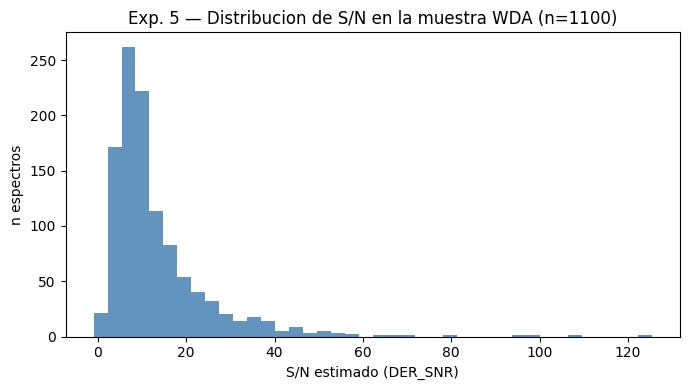

S/N: mediana=9.7, p5=3.4, p95=35.5


In [18]:
def estimate_snr_der(flux):
    """DER_SNR (Stoehr et al. 2008): estimador robusto de S/N usando solo el flujo."""
    f = np.asarray(flux, dtype=np.float64)
    f = f[np.isfinite(f)]
    if len(f) < 5:
        return np.nan
    signal = np.median(f)
    noise = 1.482602 / np.sqrt(6.0) * np.median(np.abs(2.0 * f[2:-2] - f[:-4] - f[4:]))
    return float(signal / noise) if noise > 0 else np.nan


snr_wda = np.array([estimate_snr_der(spec) for spec in X_wda_spec])

plt.figure(figsize=(7, 4))
plt.hist(snr_wda[np.isfinite(snr_wda)], bins=40, color="steelblue", alpha=0.85)
plt.xlabel("S/N estimado (DER_SNR)"); plt.ylabel("n espectros")
plt.title("Exp. 5 — Distribucion de S/N en la muestra WDA (n=1100)")
plt.tight_layout(); plt.show()

print(f"S/N: mediana={np.nanmedian(snr_wda):.1f}, "
      f"p5={np.nanpercentile(snr_wda, 5):.1f}, p95={np.nanpercentile(snr_wda, 95):.1f}")

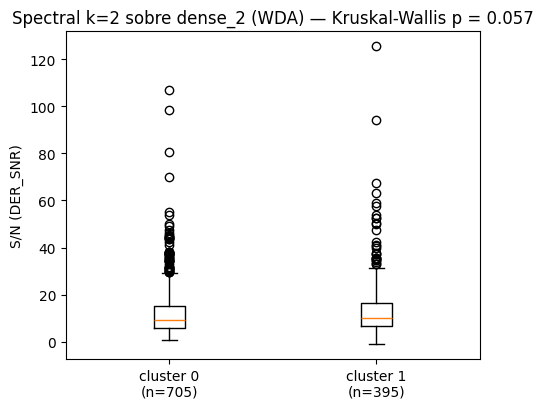

Spectral k=2 sobre dense_2 (WDA): medianas de S/N por grupo = {'cluster 0': 9.5, 'cluster 1': 10.3}, p = 0.05698


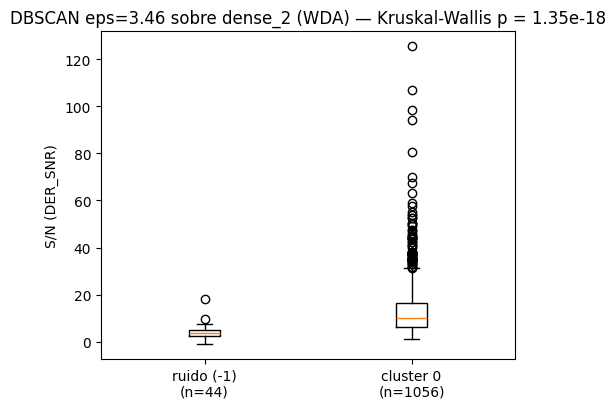

DBSCAN eps=3.46 sobre dense_2 (WDA): medianas de S/N por grupo = {'ruido (-1)': 3.6, 'cluster 0': 10.1}, p = 1.348e-18


In [19]:
# S/N por cluster para las particiones de referencia
def snr_por_cluster(labels, nombre_particion):
    etiquetas = np.unique(labels)
    grupos, nombres = [], []
    for lab in etiquetas:
        vals = snr_wda[(labels == lab) & np.isfinite(snr_wda)]
        if len(vals) > 0:
            grupos.append(vals)
            nombres.append(f"ruido (-1)" if lab == -1 else f"cluster {lab}")

    fig, ax = plt.subplots(figsize=(1.8 + 1.6 * len(grupos), 4.2))
    ax.boxplot(grupos, tick_labels=[f"{n}\n(n={len(g)})" for n, g in zip(nombres, grupos)])
    if len(grupos) >= 2:
        stat, pval = kruskal(*grupos)
        ax.set_title(f"{nombre_particion} — Kruskal-Wallis p = {pval:.3g}")
    else:
        pval = np.nan
        ax.set_title(nombre_particion)
    ax.set_ylabel("S/N (DER_SNR)")
    plt.tight_layout(); plt.show()

    medianas = {n: round(float(np.median(g)), 1) for n, g in zip(nombres, grupos)}
    print(f"{nombre_particion}: medianas de S/N por grupo = {medianas}, p = {pval:.4g}")
    return pval


# particion principal de la tesis: Spectral k=2 sobre dense_2
p_spectral = snr_por_cluster(labels_spectral, "Spectral k=2 sobre dense_2 (WDA)")

# y la particion DBSCAN del experimento 2 (si formo clusters)
if m_dbscan["n_clusters"] >= 2 or m_dbscan["n_noise"] > 0:
    p_dbscan = snr_por_cluster(labels_dbscan,
                               f"DBSCAN eps={eps_d2:.2f} sobre dense_2 (WDA)")

**Qué mirar:** el p-valor y, sobre todo, la magnitud de la diferencia de medianas. Con
n = 1.100, diferencias triviales pueden dar p < 0.05: lo importante es si un cluster concentra
sistemáticamente los espectros de baja S/N. Para DBSCAN, presta atención al grupo de ruido
(−1): si su S/N es mucho menor, DBSCAN está actuando parcialmente como filtro de calidad —
un hallazgo que vale la pena reportar en la memoria.

## Experimento 6 — Test de hipótesis nula

**Motivación.** ¿Un Silhouette de 0.385 es alto o bajo? Sin una referencia, el número es
difícil de interpretar. Este experimento construye la **distribución nula**: se aplica el mismo
pipeline (Spectral Clustering sobre datos estandarizados de igual n y dimensión) a datos
gaussianos sintéticos **sin estructura de clusters**, muchas veces. El Silhouette real se
compara contra esa distribución: si lo excede ampliamente, la estructura encontrada no es
atribuible al azar ni a la tendencia del algoritmo a "encontrar" grupos donde no los hay.

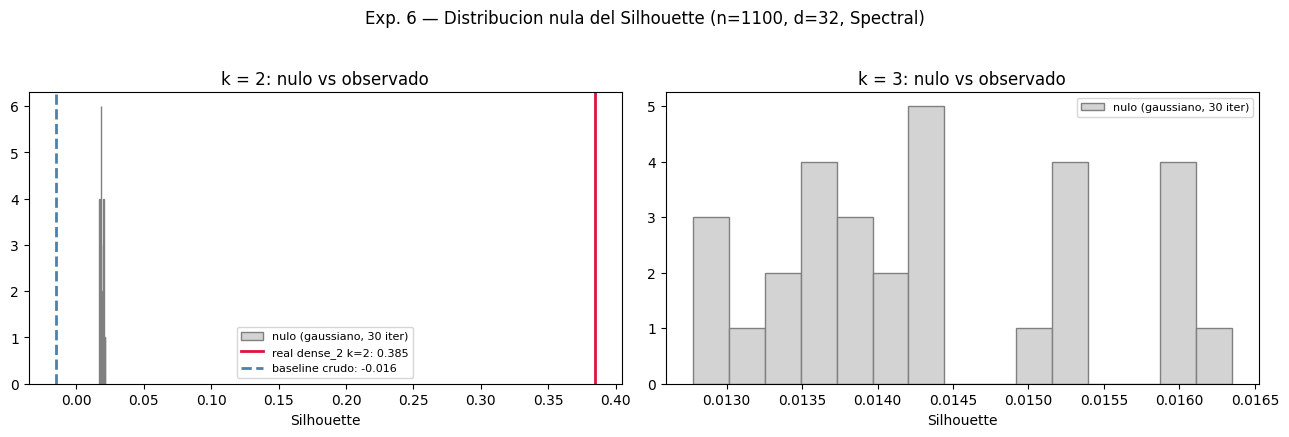

nulo k=2: media=0.0186, max=0.0214
nulo k=3: media=0.0144, max=0.0163
real dense_2 k=2: 0.3845 (excede el maximo nulo por un factor 17.9x)


In [20]:
def null_silhouette_distribution(n, d, k, n_iter=30, seed=RANDOM_STATE):
    """Silhouette de Spectral Clustering sobre datos gaussianos sin estructura."""
    rng = np.random.default_rng(seed)
    sils = []
    for i in range(n_iter):
        X_null = rng.standard_normal((n, d))
        X_null = StandardScaler().fit_transform(X_null)
        labels = SpectralClustering(n_clusters=k, affinity="nearest_neighbors",
                                    assign_labels="kmeans",
                                    random_state=int(rng.integers(0, 10_000))).fit_predict(X_null)
        sils.append(silhouette_score(X_null, labels))
    return np.array(sils)


n, d = Xs_d2.shape
null_k2 = null_silhouette_distribution(n, d, k=2, n_iter=30)
null_k3 = null_silhouette_distribution(n, d, k=3, n_iter=30)

# valores reales observados en WDA (de este mismo cuaderno)
sil_real_k2 = m_spectral["silhouette"]                      # dense_2, k=2
sil_baseline = float(tabla_exp1_piv.loc["baseline (crudo)"].max())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, null_dist, k in [(axes[0], null_k2, 2), (axes[1], null_k3, 3)]:
    ax.hist(null_dist, bins=15, color="lightgray", edgecolor="gray",
            label=f"nulo (gaussiano, {len(null_dist)} iter)")
    if k == 2:
        ax.axvline(sil_real_k2, color="crimson", lw=2,
                   label=f"real dense_2 k=2: {sil_real_k2:.3f}")
        ax.axvline(sil_baseline, color="steelblue", lw=2, ls="--",
                   label=f"baseline crudo: {sil_baseline:.3f}")
    ax.set_title(f"k = {k}: nulo vs observado")
    ax.set_xlabel("Silhouette"); ax.legend(fontsize=8)
plt.suptitle("Exp. 6 — Distribucion nula del Silhouette (n=1100, d=32, Spectral)", y=1.03)
plt.tight_layout(); plt.show()

print(f"nulo k=2: media={null_k2.mean():.4f}, max={null_k2.max():.4f}")
print(f"nulo k=3: media={null_k3.mean():.4f}, max={null_k3.max():.4f}")
print(f"real dense_2 k=2: {sil_real_k2:.4f} "
      f"(excede el maximo nulo por un factor {sil_real_k2 / null_k2.max():.1f}x)"
      if sil_real_k2 and sil_real_k2 > null_k2.max() else
      f"ATENCION: el valor real ({sil_real_k2}) NO excede el maximo nulo ({null_k2.max():.4f})")

**Qué mirar:** el valor real de `dense_2` (k=2) debería quedar muy a la derecha de toda la
distribución nula. Reporta en la memoria: media y máximo del nulo vs valor observado. Si el
baseline crudo también supera al nulo, coméntalo: significa que ya hay algo de estructura en el
flujo directo, pero la red la amplifica.

## Resumen consolidado

Tabla única con los hallazgos de los 6 experimentos, lista para transcribir a la memoria.

In [21]:
resumen = pd.DataFrame([
    {"experimento": "1. Baseline crudo",
     "resultado": f"mejor sil baseline = {sil_baseline:.3f} vs dense_2 k=2 = {sil_real_k2:.3f}"},
    {"experimento": "2. eps por k-distance",
     "resultado": ", ".join(f"{k}: {v:.2f}" for k, v in eps_sugeridos.items())},
    {"experimento": "3. k por eigengap",
     "resultado": str(resumen_eigengap)},
    {"experimento": "4. GMM (BIC)",
     "resultado": f"k={k_bic}, sil={metrics_gmm['silhouette']}"},
    {"experimento": "4. Agglomerative",
     "resultado": f"mejor k={best_k_agg}, sil={resultados_agg[best_k_agg]['silhouette']}"},
    {"experimento": "4. HDBSCAN",
     "resultado": f"mejor mcs={best_mcs}, DBCV={resultados_hdb[best_mcs]['DBCV']}, "
                  f"ruido={resultados_hdb[best_mcs]['pct_ruido']}%"},
    {"experimento": "5. S/N por cluster (Spectral k=2)",
     "resultado": f"Kruskal-Wallis p = {p_spectral:.3g}"},
    {"experimento": "6. Test nulo (k=2)",
     "resultado": f"nulo max = {null_k2.max():.3f} vs real = {sil_real_k2:.3f}"},
])
display(resumen)

,experimento,resultado
0,1. Baseline crudo,mejor sil baseline = -0.016 vs dense_2 k=2 = 0...
1,2. eps por k-distance,"baseline (crudo): 4.06, flatten: 6.57, dense: ..."
2,3. k por eigengap,"{'baseline (crudo)': 3, 'flatten': 3, 'dense':..."
3,4. GMM (BIC),"k=7, sil=0.11812599748373032"
4,4. Agglomerative,"mejor k=2, sil=0.8715519905090332"
5,4. HDBSCAN,"mejor mcs=50, DBCV=-0.18626, ruido=82.6%"
6,5. S/N por cluster (Spectral k=2),Kruskal-Wallis p = 0.057
7,6. Test nulo (k=2),nulo max = 0.021 vs real = 0.385


### Dónde va cada resultado en la memoria

- **Exp. 1** → Cap. 6, como nueva subsección al inicio de los resultados (valida la premisa del
  espacio latente). También refuerza el Resumen y las Conclusiones.
- **Exp. 2** → Cap. 6, sección de metodología de clustering (justificación de ε) y discusión
  del caso WDB.
- **Exp. 3** → Cap. 6, junto a los resultados de Spectral por capa (segunda evidencia para k).
- **Exp. 4** → Cap. 6, tabla comparativa de algoritmos; cierra la consistencia con el Cap. 4.
- **Exp. 5** → Cap. 6, discusión (robustez frente a confusores instrumentales).
- **Exp. 6** → Cap. 6, discusión (significancia de las métricas reportadas).

**Siguiente paso natural:** replicar este cuaderno para WDB y WD (cambiar `class_name` y
`n_samples`).